In [2]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from jax.scipy.special import gammaln, logsumexp
from numpyro.infer import NUTS, MCMC, Predictive, SVI
import jax.scipy.special as jsp
import jax.scipy.stats as jsstats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib_fontja

In [3]:
def nb2_logsf_normal(cap_t, mu_t, alpha):
    var_t = mu_t + (mu_t**2) / alpha
    sigma_t = jnp.sqrt(var_t)
    return jsstats.norm.logsf(cap_t - 0.5, loc=mu_t, scale=sigma_t)

In [4]:
def bass_seasonal_censored_model_normal(
    t_values,
    season_indices,
    inventory_cap,
    sales_data=None,
    season_dim=12,
    **params,
):
    # ===============================
    # 0. 入力の整形
    # ===============================
    t = jnp.asarray(t_values)
    season_indices = jnp.asarray(season_indices).astype(jnp.int32)
    cap_t = jnp.asarray(inventory_cap).astype(jnp.int32)  # 打ち切り境界（整数推奨）

    # ===============================
    # 1. パラメータ
    # ===============================

    M = numpyro.sample("M", dist.LogNormal(params['M_mu'], params['M_var']))
    log_p = numpyro.sample("log_p", dist.Normal(params['log_p_mu'], params['log_p_var']))
    log_q = numpyro.sample("log_q", dist.Normal(params['log_q_mu'], params['log_q_var']))
    p = numpyro.deterministic("p", jnp.exp(log_p))
    q = numpyro.deterministic("q", jnp.exp(log_q))

    alpha = numpyro.sample("alpha", dist.Exponential(params['alpha_var']))
# e    season_sigma = numpyro.sample("season_var", dist.HalfNormal(params['season_var']))
    # season_sigma = numpyro.sample("season_sigma", dist.HalfNormal(params.get('season_sigma_prior', 0.5)))

    # --- 季節効果：Non-Centered Parameterization (再パラメータ化) ---
    # 変更点1: 標準正規分布 N(0, 1) からサンプリングし、あとで sigma を掛ける
    # これにより、sigma と z の相関が切れ、SVIが学習しやすくなります。
#    with numpyro.plate("season_plate", season_dim):
#        z = numpyro.sample("season_z", dist.Normal(0.0, 1.0))

#    season_sigma = numpyro.sample("season_sigma", dist.HalfNormal(params['season_sigma']))
    
#    with numpyro.plate("season_plate", 12):
#        raw = numpyro.sample("raw_season", dist.Normal(0.0, 1.0))
    
    # 2. Softmax で合計 1.0 に変換
    # Softmax([x1, x2...]) = [exp(x1)/sum(exp), ...]
#    weights = jax.nn.softmax(raw * season_sigma)
    
    # 3. 平均 1.0 にするために 12 を掛ける
#    season_factors = numpyro.deterministic("season_factors", weights * season_dim)
    
#    s_raw = z * season_sigma
    concentration = numpyro.sample("conc", dist.LogNormal(0.0, params['season_sigma']))     
    
    # concentrationベクトルを作成（すべて同じ値にする場合）
    alpha_vec = jnp.ones(season_dim) * concentration

    # ディリクレ分布からサンプリング (合計は必ず 1.0 になる)
    # s_raw = [0.05, 0.15, 0.08, ...] sum=1.0
    s_raw = numpyro.sample("season_prob", dist.Dirichlet(alpha_vec))

    # 平均を1にするために、次元数(12)を掛ける
    # season_factors = [0.6, 1.8, 0.96, ...] mean=1.0
    season_factors = numpyro.deterministic("season_factors", s_raw * season_dim)

#    # 変更点2: 対数空間での Sum-to-Zero 制約（幾何平均=1 の制約）
    # 算術平均での割り算よりも勾配が安定しやすいです
#    s_centered = s_raw - jnp.mean(s_raw)
#    season_factors = numpyro.deterministic("season_factors", jnp.exp(s_centered))

    # ===============================
    # 2. Bass（連続時間・フロー）
    # ===============================
    m = p + q
    exp_term = jnp.exp(-m * t)

    # F(t) = (1 - e^{-(p+q)t}) / (1 + (q/p)e^{-(p+q)t})
    F_t = (1.0 - exp_term) / (1.0 + (q / p) * exp_term)

    # λ(t) = M (p + q F(t)) (1 - F(t))
    bass_flow = M * ((p + q * F_t) * (1.0 - F_t))

    # ===============================
    # 3. 季節性を掛けた平均需要（mu）
    # ===============================
    mu_raw = bass_flow * season_factors[season_indices]
    # mu_raw = bass_flow + s[season_indices]

    # mu >= 0 を滑らかに保証（0近傍の数値問題回避）
    mu_t = jax.nn.softplus(mu_raw)
    numpyro.deterministic("mu_pred", mu_t)

    # ===============================
    # 4. 尤度（NB2 + 右打ち切り：正規近似）
    # ===============================
    if sales_data is not None:
        y = jnp.asarray(sales_data).astype(jnp.int32)

        nb = dist.NegativeBinomial2(mean=mu_t, concentration=alpha)

        # 打ち切り判定（capが時系列）
        is_censored = y >= cap_t

        # 非打ち切り：通常のNB2
        logp_obs = nb.log_prob(y)

        # 打ち切り：log P(Y >= cap_t) を正規近似
        logp_cens = nb2_logsf_normal(cap_t, mu_t, alpha)

        # 時点ごとに切り替え、合計を factor に入れる（必ずスカラー）
        total_logp = jnp.where(is_censored, logp_cens, logp_obs)
        numpyro.factor("obs_loglik", jnp.sum(total_logp))

In [5]:
def simulate_toy_with_inventory_process(
    T=120,
    season_dim=12,
    seed=0,
    lead_time=2,          # 発注してから入荷まで（期）
    review_period=1,      # 毎期発注（1） or 隔期発注（2）など
    reorder_point=120,    # 発注点（期首在庫がこれ未満なら発注）
    target_level=220,     # 入荷後に目標とする在庫水準（order-up-to）
    base_initial_stock=200,
):
    key = jax.random.PRNGKey(seed)

    # --- 時間と季節 ---
    t_values = jnp.arange(T).astype(jnp.float32)
    season_indices = (jnp.arange(T) % season_dim).astype(jnp.int32)

    # --- 真の需要モデル（Bass×季節） ---
    M_true = 6000.0
    p_true = 0.006
    q_true = 0.22
    alpha_true = 12.0

    raw_season = jnp.array([1.15, 1.10, 1.05, 0.98, 0.95, 0.92, 0.90, 0.92, 0.96, 1.02, 1.08, 1.12])
    season_factors_true = raw_season / jnp.mean(raw_season)

    m = p_true + q_true
    exp_term = jnp.exp(-m * t_values)
    F_t = (1 - exp_term) / (1 + (q_true / p_true) * exp_term)
    bass_flow = M_true * ((p_true + q_true * F_t) * (1 - F_t))

    mu = bass_flow * season_factors_true[season_indices]
    mu = jax.nn.softplus(mu)

    # --- 在庫プロセス ---
    # 発注→lead_time 後に入荷するので、入荷待ちキューを持つ
    pipeline = jnp.zeros((lead_time,), dtype=jnp.float32)

    I = jnp.zeros((T+1,), dtype=jnp.float32).at[0].set(base_initial_stock)
    cap_t = jnp.zeros((T,), dtype=jnp.int32)
    sales = jnp.zeros((T,), dtype=jnp.int32)
    demand = jnp.zeros((T,), dtype=jnp.int32)

    def step(carry, t):
        key, I_t, pipeline = carry

        # 入荷（先頭が到着）
        arrival = pipeline[0]
        pipeline = jnp.concatenate([pipeline[1:], jnp.array([0.0])])
        I_t = I_t + arrival

        # その期の cap は期首在庫（整数）
        cap = jnp.maximum(I_t, 0.0).astype(jnp.int32)

        # 需要発生
        key, sub = jax.random.split(key)
        D_t = dist.NegativeBinomial2(mean=mu[t], concentration=alpha_true).sample(sub).astype(jnp.int32)

        # 販売（打ち切り）
        Y_t = jnp.minimum(D_t, cap)

        # 在庫消費
        I_next = I_t - Y_t

        # 発注判断：review_periodごとに、発注点割れなら order-up-to
        do_review = (t % review_period) == 0
        need_order = do_review & (I_next < reorder_point)

        # 発注量（到着後に target_level を目指す）
        order_qty = jnp.where(need_order, jnp.maximum(target_level - I_next, 0.0), 0.0)

        # pipeline 末尾に積む（lead_time後に到着）
        pipeline = pipeline.at[-1].set(pipeline[-1] + order_qty)

        new_carry = (key, I_next, pipeline)
        out = (cap, D_t, Y_t, I_next)
        return new_carry, out

    carry0 = (key, I[0], pipeline)
    _, outs = jax.lax.scan(step, carry0, jnp.arange(T))
    cap_t_f, D_f, Y_f, I_end_f = outs

    inventory_cap_t = cap_t_f.astype(jnp.int32)
    demand = D_f.astype(jnp.int32)
    sales = Y_f.astype(jnp.int32)

    return {
        "t_values": t_values,
        "season_indices": season_indices,
        "inventory_cap": inventory_cap_t,
        "sales_data": sales,
        "truth": {
            "M": M_true, "p": p_true, "q": q_true, "alpha": alpha_true,
            "season_factors": season_factors_true, "mu": mu,
            "demand": demand,
        },
        "diagnostics": {
            "censor_rate": jnp.mean(sales >= inventory_cap_t),
            "cap_min": inventory_cap_t.min(),
            "cap_max": inventory_cap_t.max(),
        }
    }

In [6]:
# res = simulate_toy_with_inventory_process()

In [7]:
params = {}
params['M_mu'] = jnp.log(5000.0)
params['M_var'] = 0.3
params['log_p_mu'] = -5.0
params['log_p_var'] = 1.0
params['log_q_mu'] = -1.5
params['log_q_var'] = 0.5
params['alpha_var'] = 1.0
params['season_sigma'] = 0.3

In [8]:
# season_indices

In [9]:
toy = simulate_toy_with_inventory_process()
t_values = toy["t_values"]
season_indices = toy["season_indices"]
cap_t = toy["inventory_cap"]
y_obs = toy["sales_data"]
truth = toy["truth"]

seed_mcmc = 21
nuts = NUTS(bass_seasonal_censored_model_normal)
mcmc = MCMC(nuts, num_warmup=1000, num_samples=2000, num_chains=1, progress_bar=True)

mcmc.run(
    jax.random.PRNGKey(seed_mcmc),
    t_values,
    season_indices,
    cap_t,
    y_obs,
    season_dim=12,
    **params
)
mcmc.print_summary()
posterior = mcmc.get_samples()

sample: 100%|█| 3000/3000 [00:02<00:00, 1068.89it/s, 15 steps of size 2.80e-01. 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
              M   7123.67    833.79   7054.14   5837.53   8465.57   1486.48      1.00
          alpha      6.03      1.71      5.81      3.19      8.59   2210.47      1.00
           conc      1.64      0.46      1.57      0.92      2.34   3468.59      1.00
          log_p     -5.24      0.19     -5.23     -5.54     -4.92   1442.68      1.00
          log_q     -1.47      0.05     -1.47     -1.55     -1.38   1337.37      1.00
 season_prob[0]      0.10      0.02      0.10      0.07      0.14   3184.35      1.00
 season_prob[1]      0.09      0.02      0.09      0.06      0.12   3613.46      1.00
 season_prob[2]      0.09      0.02      0.09      0.06      0.13   3552.88      1.00
 season_prob[3]      0.08      0.02      0.07      0.05      0.11   3675.94      1.00
 season_prob[4]      0.07      0.02      0.07      0.04      0.10   2853.62      1.00
 season_prob[5]      0.06      0.02      0.06      0.

In [10]:
predictive = Predictive(bass_seasonal_censored_model_normal, num_samples=10000)

rng_key = jax.random.PRNGKey(42)
prior_params = {
    "M_mu": jnp.log(1_000), 
    "M_var": 0.5,
    "log_p_mu": jnp.log(0.03),
    "log_p_var": 0.25,
    "log_q_mu": jnp.log(0.25),
    "log_q_var": 0.25,
    "alpha_var": 1.0,
    "season_sigma": 0.03,
}

# sales_data=None とすることで、尤度計算（観測データとの照合）をスキップさせます
prior_samples = predictive(
    rng_key, 
    t_values=t_values, 
    season_indices=season_indices, 
    inventory_cap=cap_t,
    sales_data=None, 
    **prior_params
)

<Axes: ylabel='Frequency'>

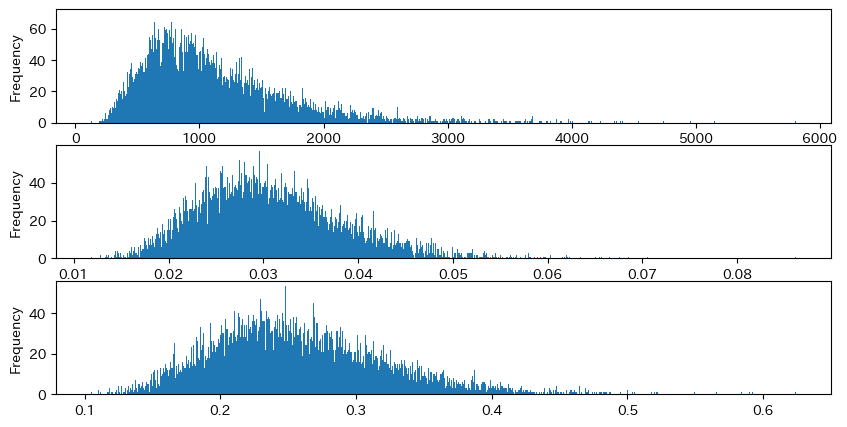

In [11]:
# Prior Sampling

# M, p, q
fig, ax = plt.subplots(3, 1, figsize=(10, 5))
pd.Series(prior_samples['M']).plot(kind='hist', bins=1000, ax=ax[0])
pd.Series(prior_samples['p']).plot(kind='hist', bins=1000, ax=ax[1])
pd.Series(prior_samples['q']).plot(kind='hist', bins=1000, ax=ax[2])

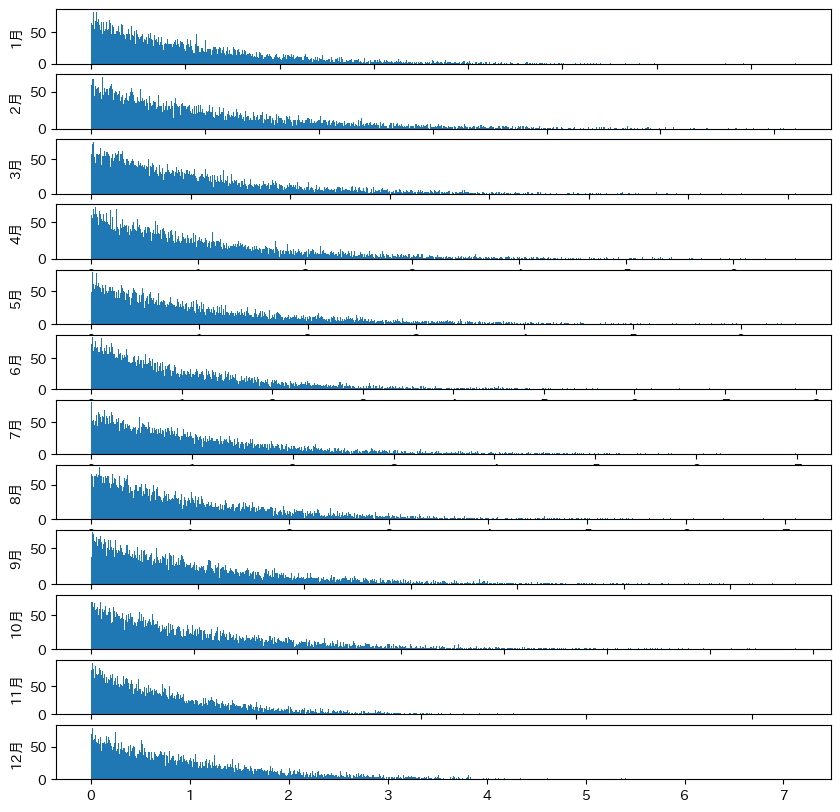

In [12]:
fig, ax = plt.subplots(12, figsize=(10, 10))
for n in range(12):
    pd.DataFrame(prior_samples['season_factors'])[n].plot(kind='hist', ax=ax[n], bins=1000)
    ax[n].set_ylabel(f"{n+1}月")

<Axes: >

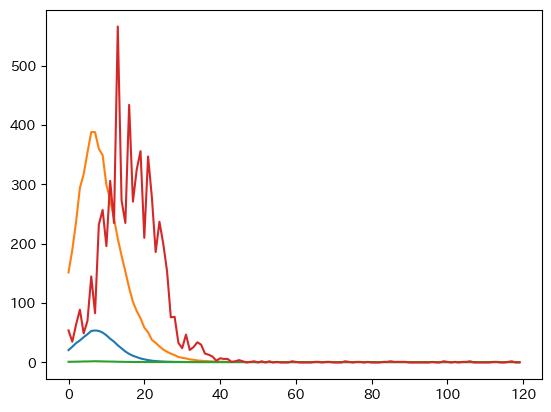

In [13]:
pd.DataFrame(prior_samples['mu_pred']).median().plot()
pd.DataFrame(prior_samples['mu_pred']).quantile(0.975).plot()
pd.DataFrame(prior_samples['mu_pred']).quantile(0.025).plot()
# pd.Series(y_obs).plot()
pd.Series(truth['demand']).plot()

In [14]:
def meta_model(t_values, season_indices, inventory_cap, sales_data, **init_params):   
    M_mu_optim = numpyro.param("M_mu_opt", init_params["M_mu"]) 
    M_var_optim = numpyro.param("M_var_opt", init_params["M_var"], constraint=dist.constraints.positive)
    
    log_p_mu_optim = numpyro.param("log_p_mu_opt", init_params["log_p_mu"])
    log_p_var_optim = numpyro.param("log_p_var_opt", init_params["log_p_var"], constraint=dist.constraints.positive)
    
    log_q_mu_optim = numpyro.param("log_q_mu_opt", init_params["log_q_mu"])
    log_q_var_optim = numpyro.param("log_q_var_opt", init_params["log_q_var"], constraint=dist.constraints.positive)
    
    season_var_optim = numpyro.param("season_sigma_opt", init_params["season_sigma"], constraint=dist.constraints.positive)    
    alpha_var_optim = numpyro.param("alpha_var_opt", init_params["alpha_var"], constraint=dist.constraints.positive)

    # 辞書にまとめて元のモデルに渡す
    learned_params = {
        'M_mu': M_mu_optim, 
        'M_var': M_var_optim,
        'log_p_mu': log_p_mu_optim, 
        'log_p_var': log_p_var_optim,
        'log_q_mu': log_q_mu_optim, 
        'log_q_var': log_q_var_optim,
        'season_sigma':season_var_optim,
        'alpha_var': alpha_var_optim
    }
    
    # 元のモデルを呼び出す
    bass_seasonal_censored_model_normal(
        t_values, season_indices, inventory_cap, sales_data, **learned_params
    )

In [16]:
season_indices

Array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,  0,  1,  2,  3,  4,
        5,  6,  7,  8,  9, 10, 11,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9,
       10, 11,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,  0,  1,  2,
        3,  4,  5,  6,  7,  8,  9, 10, 11,  0,  1,  2,  3,  4,  5,  6,  7,
        8,  9, 10, 11,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,  0,
        1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,  0,  1,  2,  3,  4,  5,
        6,  7,  8,  9, 10, 11,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       11], dtype=int32)

In [73]:
# stochastic variational inference
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoDelta, AutoMultivariateNormal, AutoLowRankMultivariateNormal
optimizer = numpyro.optim.Adam(step_size=0.001)
guide = AutoDelta(meta_model)
guide = AutoMultivariateNormal(meta_model)
guide = AutoLowRankMultivariateNormal(meta_model, rank=20)
svi = SVI(meta_model, guide, optimizer, loss=Trace_ELBO())

# 3. 実行（ハイパーパラメータの最適化）a
svi_result = svi.run(jax.random.PRNGKey(0), 1000, 
                     t_values=t_values, 
                     season_indices=season_indices, 
                     inventory_cap=cap_t, 
                     sales_data=y_obs,
                     **prior_params
                    )

100%|█████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1121.91it/s, init loss: 341592.4062, avg. loss [951-1000]: 256861.5000]


In [74]:
optimized_params = svi_result.params

params = dict()
params["M_mu"] = optimized_params["M_mu_opt"]
params["M_var"] = optimized_params["M_var_opt"]
params["log_p_mu"] = optimized_params["log_p_mu_opt"]
params["log_p_var"] = optimized_params["log_p_var_opt"]
params["log_q_mu"] = optimized_params["log_q_mu_opt"]
params["log_q_var"] = optimized_params["log_q_var_opt"]
params["season_sigma"] = optimized_params["season_sigma_opt"]
params["alpha_var"] = optimized_params["alpha_var_opt"]

In [75]:
# optimized_params

In [76]:
seed_mcmc = 21
nuts = NUTS(bass_seasonal_censored_model_normal)
mcmc = MCMC(nuts, num_warmup=1000, num_samples=2000, num_chains=1, progress_bar=True)

mcmc.run(
    jax.random.PRNGKey(seed_mcmc),
    t_values,
    season_indices,
    cap_t,
    y_obs,
    season_dim=12,
    **params
)

sample: 100%|██████████████████████████████████████████████████████████████████████| 3000/3000 [00:03<00:00, 981.15it/s, 15 steps of size 2.75e-01. acc. prob=0.93]


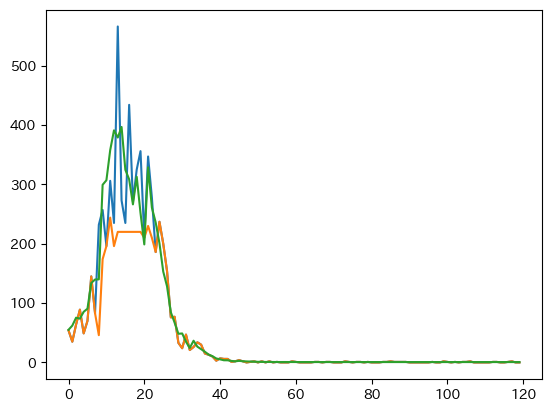

In [77]:
plt.plot(truth['demand'])
plt.plot(y_obs)
plt.plot(pd.DataFrame(mcmc.get_samples()['mu_pred']).median())

In [78]:
# pd.DataFrame(mcmc.get_samples()['season_factors']).mean(axis=0)

In [79]:
# 自動的にパラメータの最適化を実施する

In [80]:
# あとは季節性だけ

In [25]:
# pd.DataFrame(mcmc.get_samples()['season_factors']).mean(axis=0)